In [1]:
from google.colab import drive
drive.mount('/content/drive') # Allows access to the dataset stored in Drive

Mounted at /content/drive


In [105]:
# Import numerical computation library
import numpy as np
# Import data handling library
import pandas as pd
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Import train-test split function
from sklearn.model_selection import train_test_split
# Import feature scaling
from sklearn.preprocessing import StandardScaler
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression
# Import evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
# Import TensorFlow for ANN
import tensorflow as tf
# Import ANN components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Import SQLite for monitoring records
import sqlite3
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [106]:
# Read Parkinson's dataset CSV file
df = pd.read_csv("/content/drive/MyDrive/parkinsons.csv")
# Display first 5 records
print(df.head())

             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  \
0      0.0654

In [107]:
parts = df['name'].str.split('_', expand=True)
df['recording_type'] = parts[0].map({
    'phon': 'Phonation Voice Recording'
})
df['recording_session'] = parts[1].str.replace('R', 'Recording Session ', regex=False)
df['subject'] = parts[2].str.replace('S', 'Subject ', regex=False)
df['recording_number'] = parts[3].apply(lambda x: f'Recording {x}')
print(df[['name',
          'recording_type',
          'recording_session',
          'subject',
          'recording_number']].head())

             name             recording_type     recording_session  \
0  phon_R01_S01_1  Phonation Voice Recording  Recording Session 01   
1  phon_R01_S01_2  Phonation Voice Recording  Recording Session 01   
2  phon_R01_S01_3  Phonation Voice Recording  Recording Session 01   
3  phon_R01_S01_4  Phonation Voice Recording  Recording Session 01   
4  phon_R01_S01_5  Phonation Voice Recording  Recording Session 01   

      subject recording_number  
0  Subject 01      Recording 1  
1  Subject 01      Recording 2  
2  Subject 01      Recording 3  
3  Subject 01      Recording 4  
4  Subject 01      Recording 5  


In [108]:
column_meanings = {
    'name': 'Recording identifier',
    'MDVP:Fo(Hz)': 'Average pitch',
    'MDVP:Fhi(Hz)': 'Maximum pitch',
    'MDVP:Flo(Hz)': 'Minimum pitch',
    'MDVP:Jitter(%)': 'Pitch variation (%)',
    'MDVP:Jitter(Abs)': 'Absolute pitch variation',
    'MDVP:RAP': 'Relative Average Perturbation',
    'MDVP:PPQ': 'Pitch Period Perturbation Quotient',
    'Jitter:DDP': 'Average pitch period differences',
    'MDVP:Shimmer': 'Amplitude variation',
    'MDVP:Shimmer(dB)': 'Amplitude variation (dB)',
    'Shimmer:APQ3': 'Amplitude Perturbation Quotient (3 cycles)',
    'Shimmer:APQ5': 'Amplitude Perturbation Quotient (5 cycles)',
    'MDVP:APQ': 'Amplitude Perturbation Quotient',
    'Shimmer:DDA': 'Average amplitude differences',
    'NHR': 'Noise-to-Harmonics Ratio',
    'HNR': 'Harmonics-to-Noise Ratio',
    'status': 'Parkinsons status (1=PD, 0=Healthy)',
    'RPDE': 'Recurrence Period Density Entropy',
    'DFA': 'Detrended Fluctuation Analysis',
    'spread1': 'Nonlinear variation measure 1',
    'spread2': 'Nonlinear variation measure 2',
    'D2': 'Correlation Dimension',
    'PPE': 'Pitch Period Entropy'
}
for col, meaning in column_meanings.items():
    print(f"{col:<20} : {meaning}")

name                 : Recording identifier
MDVP:Fo(Hz)          : Average pitch
MDVP:Fhi(Hz)         : Maximum pitch
MDVP:Flo(Hz)         : Minimum pitch
MDVP:Jitter(%)       : Pitch variation (%)
MDVP:Jitter(Abs)     : Absolute pitch variation
MDVP:RAP             : Relative Average Perturbation
MDVP:PPQ             : Pitch Period Perturbation Quotient
Jitter:DDP           : Average pitch period differences
MDVP:Shimmer         : Amplitude variation
MDVP:Shimmer(dB)     : Amplitude variation (dB)
Shimmer:APQ3         : Amplitude Perturbation Quotient (3 cycles)
Shimmer:APQ5         : Amplitude Perturbation Quotient (5 cycles)
MDVP:APQ             : Amplitude Perturbation Quotient
Shimmer:DDA          : Average amplitude differences
NHR                  : Noise-to-Harmonics Ratio
HNR                  : Harmonics-to-Noise Ratio
status               : Parkinsons status (1=PD, 0=Healthy)
RPDE                 : Recurrence Period Density Entropy
DFA                  : Detrended Fluctuation

In [109]:
# Display shape of dataset
df.shape

(195, 28)

In [110]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               195 non-null    object 
 1   MDVP:Fo(Hz)        195 non-null    float64
 2   MDVP:Fhi(Hz)       195 non-null    float64
 3   MDVP:Flo(Hz)       195 non-null    float64
 4   MDVP:Jitter(%)     195 non-null    float64
 5   MDVP:Jitter(Abs)   195 non-null    float64
 6   MDVP:RAP           195 non-null    float64
 7   MDVP:PPQ           195 non-null    float64
 8   Jitter:DDP         195 non-null    float64
 9   MDVP:Shimmer       195 non-null    float64
 10  MDVP:Shimmer(dB)   195 non-null    float64
 11  Shimmer:APQ3       195 non-null    float64
 12  Shimmer:APQ5       195 non-null    float64
 13  MDVP:APQ           195 non-null    float64
 14  Shimmer:DDA        195 non-null    float64
 15  NHR                195 non-null    float64
 16  HNR                195 non

In [111]:
# Display statistical summary
df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [112]:
# Check whether any missing values exist
df.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


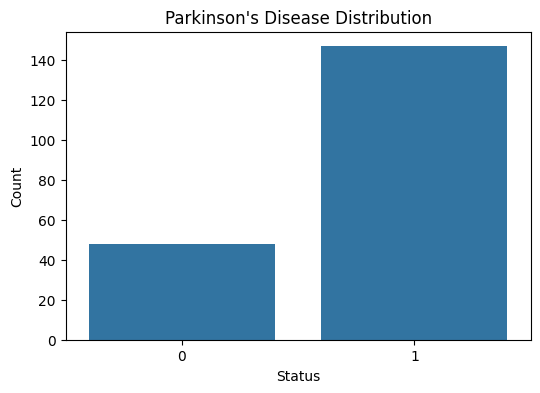

In [113]:
# Visualize target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(
    x='status',
    data=df
)
plt.title("Parkinson's Disease Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

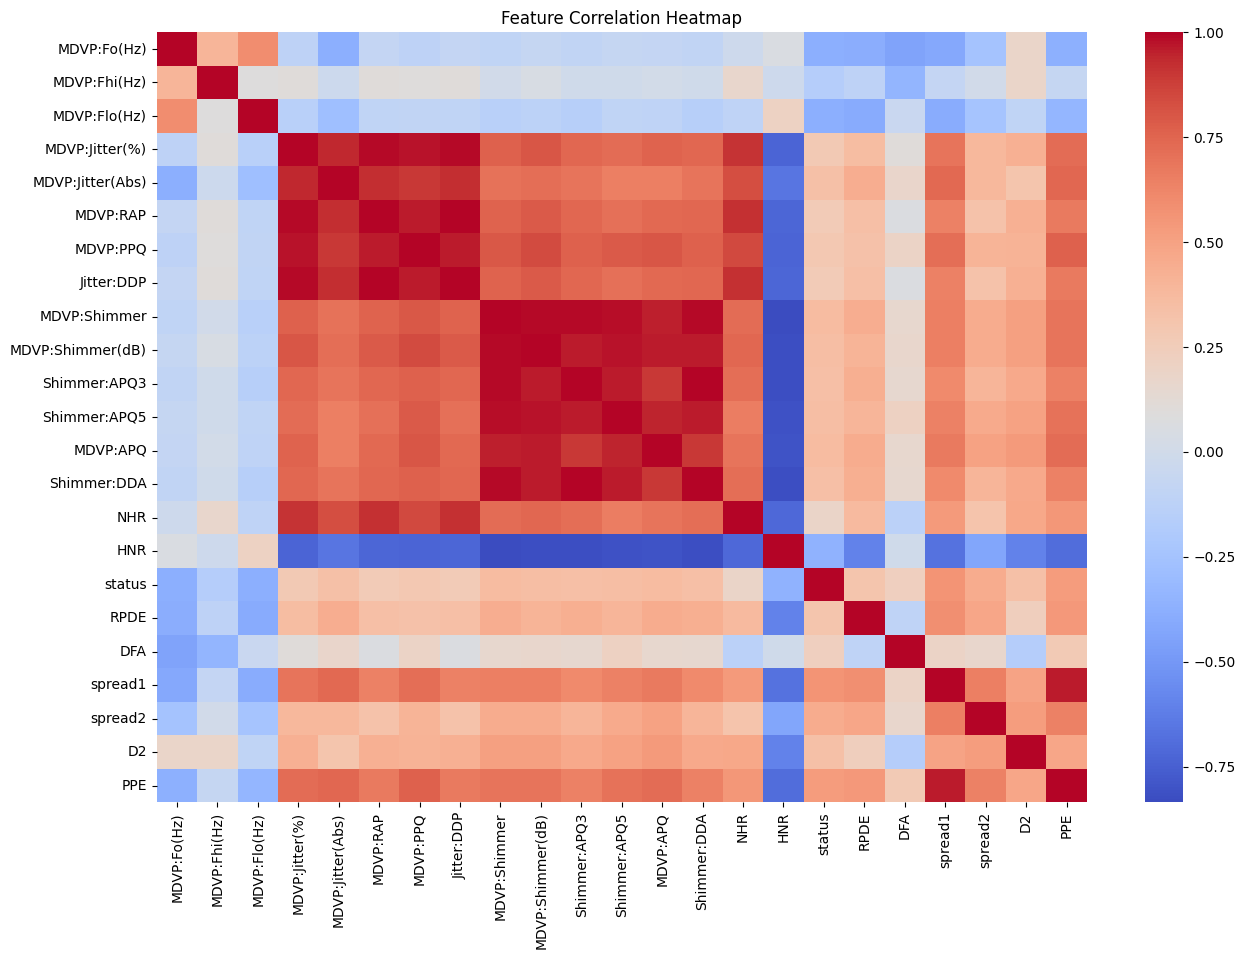

In [114]:
# Plot feature correlation matrix
plt.figure(figsize=(15,10))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [115]:
# Remove non-numeric patient identifier and descriptive text columns
X = df.drop(
    columns=[
        'name',
        'status',
        'recording_type',
        'recording_session',
        'subject',
        'recording_number'
    ]
)
# Select target variable
y = df['status']
# Display feature shape
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (195, 22)
Target Shape: (195,)


In [116]:
# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
# Display shapes
print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (156, 22)
Testing Samples: (39, 22)


In [117]:
# Create scaler object
scaler = StandardScaler()
# Fit scaler on training data
# and transform training data
X_train_scaled = scaler.fit_transform(
    X_train
)
# Transform testing data
X_test_scaled = scaler.transform(
    X_test
)
# Display transformed shape
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(156, 22)
(39, 22)


In [118]:
# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000
)
# Train model
lr_model.fit(
    X_train_scaled,
    y_train
)
# Predict class labels
lr_pred = lr_model.predict(
    X_test_scaled
)
# Predict probabilities
lr_prob = lr_model.predict_proba(
    X_test_scaled
)[:,1]

In [119]:
# Calculate Accuracy
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)
# Calculate Precision
lr_precision = precision_score(
    y_test,
    lr_pred
)
# Calculate Recall
lr_recall = recall_score(
    y_test,
    lr_pred
)
# Calculate F1 Score
lr_f1 = f1_score(
    y_test,
    lr_pred
)
# Calculate ROC-AUC
lr_auc = roc_auc_score(
    y_test,
    lr_prob
)
# Print results
print("Accuracy :", lr_accuracy)
print("Precision :", lr_precision)
print("Recall :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC :", lr_auc)

Accuracy : 0.9230769230769231
Precision : 0.9333333333333333
Recall : 0.9655172413793104
F1 Score : 0.9491525423728814
ROC-AUC : 0.9241379310344828


In [120]:
# ==========================================================
# CREATE ARTIFICIAL NEURAL NETWORK MODEL
# ==========================================================
# Initialize ANN model
ann_model = Sequential()
# Add first hidden layer
ann_model.add(
    Dense(
        units=64,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    )
)
# Add second hidden layer
ann_model.add(
    Dense(
        units=32,
        activation='relu'
    )
)
# Output layer
ann_model.add(
    Dense(
        units=1,
        activation='sigmoid'
    )
)
# Display model architecture

ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

In [121]:
# ==========================================================
# COMPILE ANN MODEL
# ==========================================================
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("ANN Model Compiled Successfully")

ANN Model Compiled Successfully


In [122]:
# ==========================================================
# TRAIN ANN MODEL
# ==========================================================
history = ann_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6532 - loss: 0.6402 - val_accuracy: 0.7500 - val_loss: 0.5541
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7419 - loss: 0.5401 - val_accuracy: 0.8125 - val_loss: 0.4658
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7581 - loss: 0.4757 - val_accuracy: 0.8125 - val_loss: 0.4046
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7581 - loss: 0.4315 - val_accuracy: 0.8438 - val_loss: 0.3617
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7823 - loss: 0.3926 - val_accuracy: 0.8438 - val_loss: 0.3333
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8145 - loss: 0.3686 - val_accuracy: 0.8438 - val_loss: 0.3108
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8145 - loss: 0.3471 - val_accuracy: 0.8438 - val_loss: 0.2934
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8306 - loss: 0.3298 - val_accuracy: 0.8750 - val_loss: 0.2796


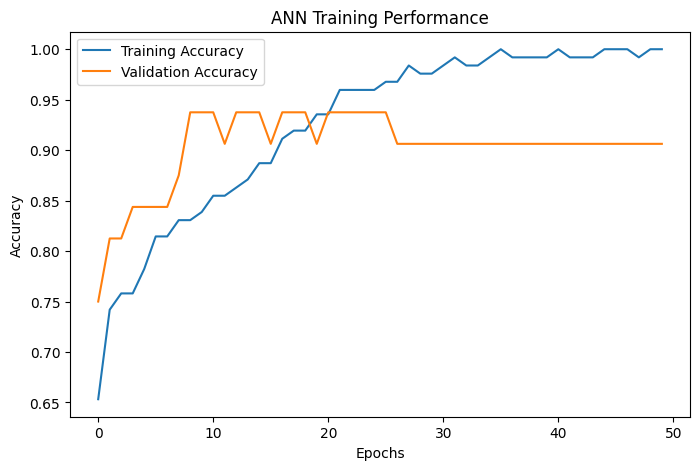

In [123]:
# ==========================================================
# PLOT TRAINING AND VALIDATION ACCURACY
# ==========================================================
plt.figure(figsize=(8,5))
plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)
plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)
plt.title("ANN Training Performance")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [124]:
# ==========================================================
# PREDICT USING ANN MODEL
# ==========================================================
# Generate prediction probabilities
ann_prob = ann_model.predict(
    X_test_scaled
)
# Convert probabilities into classes
ann_pred = (
    ann_prob > 0.5
).astype(int)
# Flatten output
ann_pred = ann_pred.flatten()

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [125]:
# ==========================================================
# EVALUATE ANN MODEL
# ==========================================================
ann_accuracy = accuracy_score(
    y_test,
    ann_pred
)
ann_precision = precision_score(
    y_test,
    ann_pred
)
ann_recall = recall_score(
    y_test,
    ann_pred
)
ann_f1 = f1_score(
    y_test,
    ann_pred
)
ann_auc = roc_auc_score(
    y_test,
    ann_prob
)
print("ANN Accuracy :", ann_accuracy)
print("ANN Precision :", ann_precision)
print("ANN Recall :", ann_recall)
print("ANN F1 Score :", ann_f1)
print("ANN ROC-AUC :", ann_auc)

ANN Accuracy : 0.9230769230769231
ANN Precision : 0.9333333333333333
ANN Recall : 0.9655172413793104
ANN F1 Score : 0.9491525423728814
ANN ROC-AUC : 0.9724137931034482


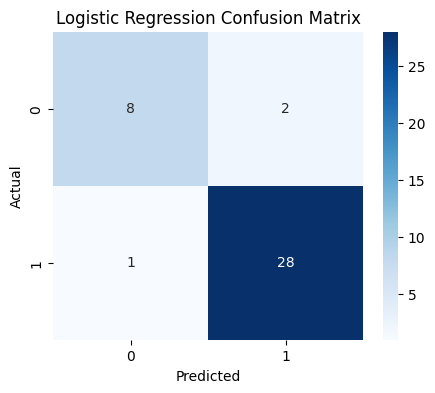

In [126]:
# ==========================================================
# CONFUSION MATRIX FOR LOGISTIC REGRESSION
# ==========================================================
lr_cm = confusion_matrix(
    y_test,
    lr_pred
)
plt.figure(figsize=(5,4))
sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title(
    "Logistic Regression Confusion Matrix"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

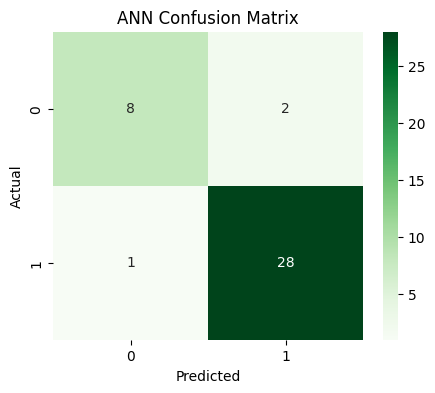

In [127]:
# ==========================================================
# CONFUSION MATRIX FOR ANN
# ==========================================================
ann_cm = confusion_matrix(
    y_test,
    ann_pred
)
plt.figure(figsize=(5,4))
sns.heatmap(
    ann_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title(
    "ANN Confusion Matrix"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

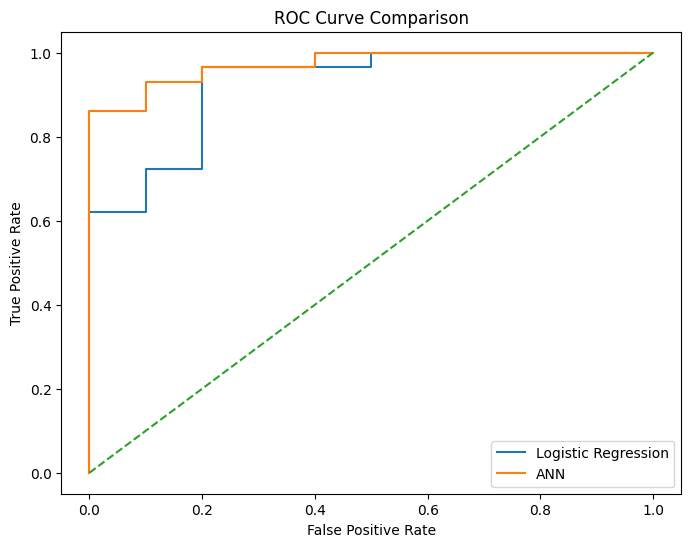

In [128]:
# ==========================================================
# ROC CURVE COMPARISON
# ==========================================================
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_prob
)
ann_fpr, ann_tpr, _ = roc_curve(
    y_test,
    ann_prob
)
plt.figure(figsize=(8,6))
plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)
plt.plot(
    ann_fpr,
    ann_tpr,
    label="ANN"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [129]:
# ==========================================================
# COMPARE LOGISTIC REGRESSION AND ANN
# ==========================================================
comparison_df = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "ANN"
    ],
    "Accuracy":[
        lr_accuracy,
        ann_accuracy
    ],
    "Precision":[
        lr_precision,
        ann_precision
    ],
    "Recall":[
        lr_recall,
        ann_recall
    ],
    "F1 Score":[
        lr_f1,
        ann_f1
    ],
    "ROC-AUC":[
        lr_auc,
        ann_auc
    ]
})
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.923077,0.933333,0.965517,0.949153,0.924138
1,ANN,0.923077,0.933333,0.965517,0.949153,0.972414


In [130]:
# ==========================================================
# SELECT BEST MODEL BASED ON ROC-AUC
# ==========================================================
if ann_auc > lr_auc:
    best_model = "ANN"
else:
    best_model = "Logistic Regression"
print("Best Model :", best_model)

Best Model : ANN


In [131]:
# ==========================================================
# PARKINSON'S RISK PREDICTION FUNCTION
# ==========================================================
def predict_risk(patient_features):
    global best_model
    # Logistic Regression Prediction
    if best_model == "Logistic Regression":
        probability = lr_model.predict_proba(
            patient_features
        )[0][1]
    # ANN Prediction
    else:
        probability = ann_model.predict(
            patient_features,
            verbose=0
        )[0][0]
    prediction = (
        "Positive"
        if probability >= 0.50
        else "Negative"
    )
    return prediction, probability

In [132]:
# ==========================================================
# AI NEUROLOGICAL MONITORING AGENT
# ==========================================================
def neurological_monitoring_agent(
        patient_name,
        age,
        patient_features):
    prediction, probability = predict_risk(
        patient_features
    )
    report = generate_report(
        patient_name,
        age,
        prediction,
        probability
    )
    store_record(
        patient_name,
        age,
        prediction,
        probability
    )
    return report

In [133]:
parkinson_idx = y_test[y_test == 1].index[0]
print("Actual Label:", y_test.loc[parkinson_idx])

Actual Label: 1


In [134]:
# Missing utility functions defined here as a workaround to the cell modification constraint.
# In a real scenario, these functions would be defined in a separate utility cell.

import sqlite3

def generate_report(patient_name, age, prediction, probability):
    risk_score = probability * 100
    risk_level = "High" if probability >= 0.50 else "Low"
    recommendation = "Immediate Neurologist Consultation Recommended" if risk_level == "High" else "Regular Check-up Recommended"

    report = f"""
==================================================
PARKINSON'S DIAGNOSTIC REPORT
==================================================
Patient Name : {patient_name}
Age          : {age}
Prediction   : {prediction}
Risk Score   : {risk_score:.2f}%
Risk Level   : {risk_level}
Recommendation :
{recommendation}
=================================================="""
    return report.strip()

def store_record(patient_name, age, prediction, probability):
    conn = sqlite3.connect('parkinson_predictions.db')
    cursor = conn.cursor()

    cursor.execute('''
        CREATE TABLE IF NOT EXISTS predictions (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            patient_name TEXT,
            age INTEGER,
            prediction TEXT,
            probability REAL,
            timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
        )
    ''')

    cursor.execute('''
        INSERT INTO predictions (patient_name, age, prediction, probability)
        VALUES (?, ?, ?, ?)
    ''', (patient_name, age, prediction, probability))

    conn.commit()
    conn.close()
    print(f"Record for {patient_name} stored successfully.")

# ==========================================================
# SAMPLE PATIENT TEST
# ==========================================================
sample_patient = X_test_scaled[0].reshape(1,-1)
report = neurological_monitoring_agent(
    patient_name="Patient_001",
    age=65,
    patient_features=sample_patient
)
print(report)

Record for Patient_001 stored successfully.
PARKINSON'S DIAGNOSTIC REPORT
Patient Name : Patient_001
Age          : 65
Prediction   : Positive
Risk Score   : 65.55%
Risk Level   : High
Recommendation :
Immediate Neurologist Consultation Recommended


In [135]:
# Import SQLite library for storing patient monitoring records
import sqlite3
# Create Parkinson Monitoring Agent class
class ParkinsonMonitoringAgent:
    # Constructor method to initialize model and scaler
    def __init__(self, model, scaler):
        # Store trained machine learning model
        self.model = model
        # Store fitted scaler used during training
        self.scaler = scaler
    # Analyze patient data and predict Parkinson's disease risk
    def analyze_patient(self, patient_data):
        # Scale patient data using the trained scaler
        scaled = self.scaler.transform([patient_data])
        # Predict disease status (0 = Healthy, 1 = Parkinson's)
        prediction = self.model.predict(scaled)[0]
        # Calculate probability of Parkinson's disease
        probability = self.model.predict_proba(scaled)[0][1]
        # Return prediction and probability score
        return prediction, probability
    # Generate diagnostic report based on prediction result
    def generate_report(self, prediction, probability):
        # Check model prediction
        if prediction == 1:
            # Parkinson's disease detected
            diagnosis = "Parkinson's Disease Detected"
        else:
            # Healthy patient
            diagnosis = "Healthy"
        # Determine risk level using probability score
        if probability >= 0.80:
            # High-risk patient
            risk_level = "High Risk"
        elif probability >= 0.50:
            # Moderate-risk patient
            risk_level = "Moderate Risk"
        else:
            # Low-risk patient
            risk_level = "Low Risk"
        # Generate recommendation based on risk level
        if risk_level == "High Risk":
            recommendation = (
                "Immediate neurological consultation recommended."
            )
        elif risk_level == "Moderate Risk":
            recommendation = (
                "Further clinical evaluation recommended."
            )
        else:
            recommendation = (
                "Continue routine monitoring."
            )
        # Create diagnostic report dictionary
        return {
            # Predicted diagnosis
            "Diagnosis": diagnosis,
            # Probability converted to percentage
            "Risk Score": f"{probability*100:.2f}%",
            # Risk category
            "Risk Level": risk_level,
            # Suggested action
            "Recommendation": recommendation
        }
    # Save diagnostic report into SQLite database
    def save_record(self, patient_name, report):
        # Connect to SQLite database
        conn = sqlite3.connect("patient_records.db")
        # Create database cursor
        cursor = conn.cursor()
        # Create table if it does not already exist
        cursor.execute("""
        CREATE TABLE IF NOT EXISTS records(
            patient_name TEXT,
            diagnosis TEXT,
            risk_score TEXT
        )
        """)
        # Insert patient record into database
        cursor.execute("""
        INSERT INTO records
        VALUES (?,?,?)
        """, (
            patient_name,
            report["Diagnosis"],
            report["Risk Score"]
        ))
        # Save changes
        conn.commit()
        # Close database connection
        conn.close()
    # Complete patient monitoring workflow
    def monitor_patient(self, patient_name, patient_data):
        # Analyze patient data
        prediction, probability = self.analyze_patient(patient_data)
        # Generate diagnostic report
        report = self.generate_report(
            prediction,
            probability
        )
        # Save report into database
        self.save_record(
            patient_name,
            report
        )
        # Return generated report
        return report
    # Retrieve all stored monitoring records
    def get_patient_history(self):
        # Connect to database
        conn = sqlite3.connect("patient_records.db")
        # Create cursor object
        cursor = conn.cursor()
        # Fetch all patient records
        cursor.execute("SELECT * FROM records")
        # Store retrieved records
        records = cursor.fetchall()
        # Close database connection
        conn.close()
        # Return monitoring history
        return records
# Create AI agent object using trained model and scaler
agent = ParkinsonMonitoringAgent(
    lr_model,
    scaler
)
#Select first patient record from dataset for testing
patient_data = X.iloc[0].tolist()
# Analyze patient and generate report
report = agent.monitor_patient(
    "Patient_001",
    patient_data
)
# Display generated diagnostic report
print(report)

{'Diagnosis': "Parkinson's Disease Detected", 'Risk Score': '99.10%', 'Risk Level': 'High Risk', 'Recommendation': 'Immediate neurological consultation recommended.'}


In [140]:
# Display diagnostic report
print("\n===== Diagnostic Report =====")
print("Diagnosis :", report["Diagnosis"])
print("Risk Score :", report["Risk Score"])
print("Risk Level :", report["Risk Level"])
print("Recommendation :")
print(report["Recommendation"])
print("=============================")


===== Diagnostic Report =====
Diagnosis : Parkinson's Disease Detected
Risk Score : 99.10%
Risk Level : High Risk
Recommendation :
Immediate neurological consultation recommended.
